# Getting Above Ground Biomass AGB of Mekar Raya 2000 to 2025 from CTrees dataset

Based on here: [https://colab.research.google.com/drive/1RqajrmqBVo-ZNmYpKKy__RwMUvBlVcN1?usp=sharing](https://colab.research.google.com/drive/1RqajrmqBVo-ZNmYpKKy__RwMUvBlVcN1?usp=sharing)

In [ ]:
# First don't forget to create a new conda environment
# because it needs some very specific versions of some dependencies
# and you dont't want to mess up your environment.
# for creating a new conda env:
# conda create --name ctrees-agb python=3.13 -y

# Then activate you conda envirnment
# conda activate ctrees-agb

# Now lets install gdal first.
%conda install -c conda-forge gdal -y

32.42s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Channels:
 - conda-forge
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [51]:
# Install dependencies
%pip install rioxarray arraylake==1.0.0 geopandas matplotlib folium mapclassify scikit-learn

56.31s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


In [52]:
# Import everything we need
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from arraylake import Client
import rioxarray as rio

In [53]:
# Login
client = Client()
client.login()

Successfully refreshed tokens! Token stored at /Users/fmammoli/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: fmammoli@gmail.com                                                                                       │
│ Id: 8c5b2cdd-cf84-4e5d-95bd-7b9b0478bf05                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [54]:
# Set our organization info
ORGANIZATION_NAME = "beyond-carbon" ## your organizaiton name
REPOSITORY_NAME = "ctrees-agb-indonesia" ## what you decided to call the dataset!

In [55]:
# View full agb dataset
repo = client.get_repo(f"{ORGANIZATION_NAME}/{REPOSITORY_NAME}")
session = repo.readonly_session(branch="main")
ds = xr.open_zarr(session.store, zarr_format=3, group="aboveground_biomass")
ds

  2026-06-25T21:42:12.024110Z  WARN icechunk::asset_manager: A manifest with 1 chunk references is being loaded into the cache that can only keep 0 references. Consider increasing the size of the manifest cache using the num_chunk_refs field in CachingConfig
    at icechunk/src/asset_manager.rs:378



<xarray.Dataset> Size: 26TB
Dimensions:      (time: 26, y: 202500, x: 405000)
Coordinates:
  * time         (time) datetime64[D] 208B 2000-01-01 2001-01-01 ... 2025-01-01
  * y            (y) float64 2MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0 -90.0
  * x            (x) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B ...
Data variables:
    agb          (time, y, x) float32 9TB ...
    uncertainty  (time, y, x) int64 17TB ...

In [56]:
# Take a closer look at the data, especially for time dimensions and x and y, and scale factor
ds.agb

<xarray.DataArray 'agb' (time: 26, y: 202500, x: 405000)> Size: 9TB
[2132325000000 values with dtype=float32]
Coordinates:
  * time         (time) datetime64[D] 208B 2000-01-01 2001-01-01 ... 2025-01-01
  * y            (y) float64 2MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0 -90.0
  * x            (x) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:     Area
    long_name:         Above Ground Biomass
    dtype:             int16
    valid_min:         0
    valid_max:         6000
    units:             Mg ha-1
    agb_scale_factor:  10

In [57]:
# Read mekar raya shapefile
import os
from pathlib import Path

p = Path.cwd()
shp_path = p / "Mekar Raya GIS Data" / "Merge_Desa_AKKM.shp"
mekar_raya_shp_path = shp_path.resolve()

# And then read it
# Read the shapefile into a GeoDataFrame
mekar_raya_gdf = gpd.read_file(mekar_raya_shp_path)

# Ensure the GeoDataFrame is in a geographic CRS (WGS84) for Folium/explore()
mekar_raya_gdf_wgs84 = mekar_raya_gdf.to_crs(epsg=4326)

# Calculate the centroid of the GeoDataFrame for centering the map
centroid = mekar_raya_gdf_wgs84.geometry.centroid.iloc[0]
map_center = [centroid.y, centroid.x] # Folium expects [latitude, longitude]

# Print the CRS, bounds, and map center for debugging
print(f"GeoDataFrame CRS: {mekar_raya_gdf_wgs84.crs}")
minx, miny, maxx, maxy = mekar_raya_gdf_wgs84.total_bounds
print(f"GeoDataFrame Bounding Box (min_lon, min_lat, max_lon, max_lat): [{minx}, {miny}, {maxx}, {maxy}]")
print(f"Calculated Map Center (latitude, longitude): {map_center}")

GeoDataFrame CRS: EPSG:4326
GeoDataFrame Bounding Box (min_lon, min_lat, max_lon, max_lat): [110.2883397997098, -0.9288519342658742, 110.38242481889847, -0.8289397905000219]
Calculated Map Center (latitude, longitude): [-0.8623698954285385, 110.31622578594927]


/var/folders/03/4xf3v6l11kn2j0bk62m0ytvc0000gn/T/ipykernel_94907/3338958908.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = mekar_raya_gdf_wgs84.geometry.centroid.iloc[0]


In [58]:
# Create a buffer around it
# Create a 20km buffer around the map center
buffer_distance_km = 20

buffer_distance_degrees = buffer_distance_km / 111  # Approximate conversion: 1 degree ≈ 111 km, 
                                                    # because we are using WGS84 (EPSG:4326) 
                                                    # it should be in degrees

# Create a buffer geometry around the centroid
buffer_geometry = centroid.buffer(buffer_distance_degrees)

# Create a GeoDataFrame from the buffer
buffer_gdf = gpd.GeoDataFrame(
    {'geometry': [buffer_geometry]},
    crs=mekar_raya_gdf_wgs84.crs
)

In [59]:
# Now lets plot to see if we are at the right place
# Create an interactive map showing Mekar Raia Shapefile on top of a satelite basemap
# This will generate a Folium map
import xyzservices.providers as xyz
import shapely.geometry  

interactive_map = mekar_raya_gdf_wgs84.explore(
    tiles=xyz.Esri.WorldImagery,
    tooltip=False,
    style_kwds=dict(color="red", opacity=0.4, fill=True, fillOpacity=0.05),
    zoom_start=10, # Adjust initial zoom level as desired
    location=map_center # Set the initial center of the map
)

# Add the buffer to the interactive map
buffer_gdf.explore(
    m=interactive_map,
    color='blue',
    style_kwds=dict(fill=False, weight=2),
    tooltip=False
)

# Getting the buffer bounding box to use it as a bounding box for the ESA data
bbox_minx, bbox_miny, bbox_maxx, bbox_maxy = buffer_gdf.total_bounds
bbox_polygon = shapely.geometry.box(bbox_minx, bbox_miny, bbox_maxx, bbox_maxy)
bbox_gdf = gpd.GeoDataFrame({'geometry': [bbox_polygon]}, crs=buffer_gdf.crs)

bbox_gdf.explore(
    m=interactive_map,
    color='yellow',
    style_kwds=dict(fill=False, weight=1, dashArray='6, 6'),
    tooltip=False
)

# You can use this two line to save the buffer shapefile
#bbox_shp_filename = Path.cwd() / "mekar_raya_20km_buffer" / "mekar_raya_20km_buffer_bbox.shp"
#bbox_gdf.to_file(bbox_shp_filename, driver="ESRI Shapefile", index=False)
print(f"BBox (min_lon, min_lat, max_lon, max_lat): [{minx}, {miny}, {maxx}, {maxy}]")

# Display the interactive map
interactive_map

BBox (min_lon, min_lat, max_lon, max_lat): [110.2883397997098, -0.9288519342658742, 110.38242481889847, -0.8289397905000219]


# If the maps does not show up or if a message saying that you need to trust something shows up or it it is all grey, just create a markdown cell bellow it that it will solve the issue. Weird bug and weird solution!

In [60]:
# Defining our Area of Interest (AOI)
bbox = [bbox_minx, bbox_miny, bbox_maxx, bbox_maxy]

da_clip = ds.agb.sel(
    x=slice(bbox_minx, bbox_maxx),
    y=slice(bbox_maxy, bbox_miny),
) / ds.agb.attrs.get("agb_scale_factor")

2000


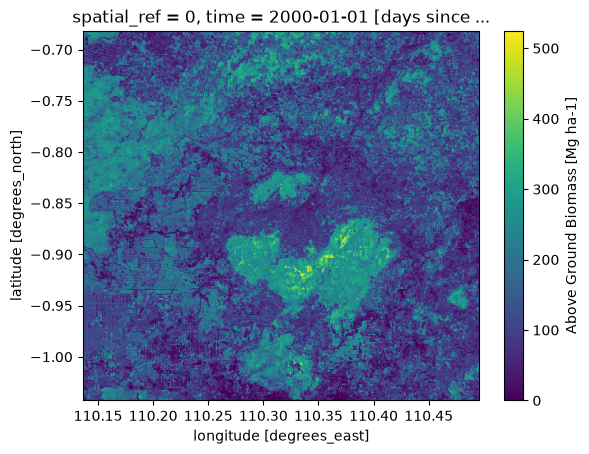

In [61]:
# Now lets plot a few years
year_one = 2000
year_two = 2003

print(year_one)
da_clip.sel(time=f"{year_one}-01-01").plot()

2003


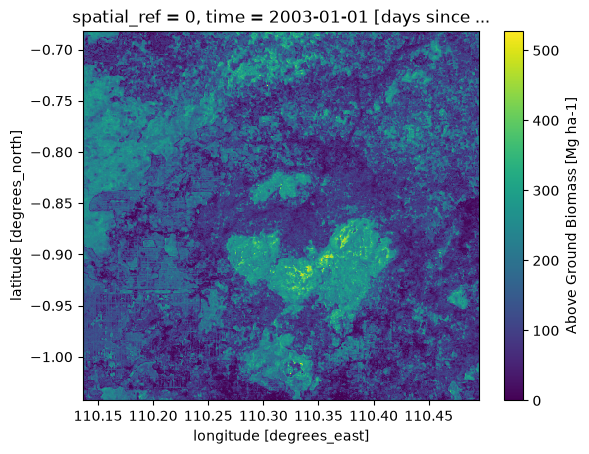

In [62]:
# Lets print another year
print(year_two)
da_clip.sel(time=f"{year_two}-01-01").plot()

In [63]:
# Lets save the output as a geotiff
da_year = da_clip.sel(time=f"{year_one}-01-01")

# Should probably make a more sane Path resolution with os or pathlib
filename = f"./CTRees_AGB/my_bbox_{year_one}-01-01.tif"

# It needs the path as a string so we use the as_posix()
da_year.rio.to_raster(filename,
    tiled=True,       # better layout for partial reads
    windowed=True,    # avoids loading everything into memory at once
    compress="LZW",
)

<Axes: >

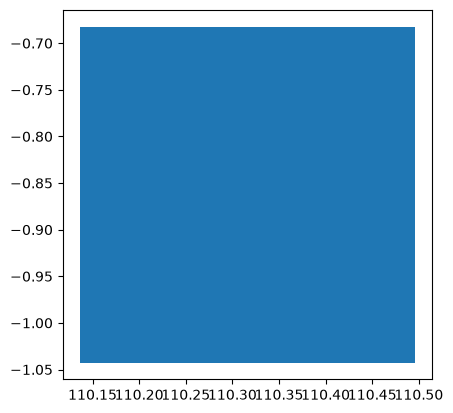

In [64]:
# Plot a geometry
gdf = gpd.read_file("./mekar_raya_20km_buffer/mekar_raya_20km_buffer_bbox.shp")
gdf.geometry.plot()

In [81]:
geom = gdf.geometry
minx, miny, maxx, maxy = geom.total_bounds

# Keep all years but crop spatially before clipping to the polygon
da_clip = ds.agb.sel(
    x=slice(minx, maxx),
    y=slice(maxy, miny),
) / ds.agb.attrs.get("agb_scale_factor")

da_masked = da_clip.rio.clip(geom, crs="EPSG:4326", drop=True)


In [ ]:
# Save teh data of all years as a geotiff

# Should probably make a more sane Path resolution with os or pathlib
agb_all_years_filename = f"./CTRees_AGB/mekar_raya_20km-buffer_100m_2000-2025.tif"

# It needs the path as a string so we use the as_posix()
da_masked.rio.to_raster(filename,
    tiled=True,       # better layout for partial reads
    windowed=True,    # avoids loading everything into memory at once
    compress="LZW",
)

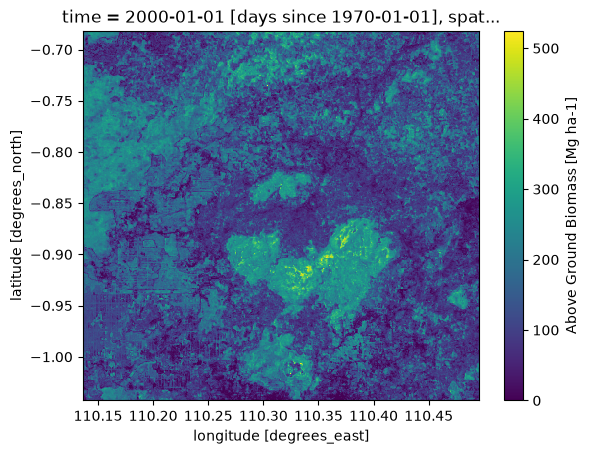

In [66]:
# Lets plot some years
da_masked.sel(time=f"{year_one}-01-01").plot()

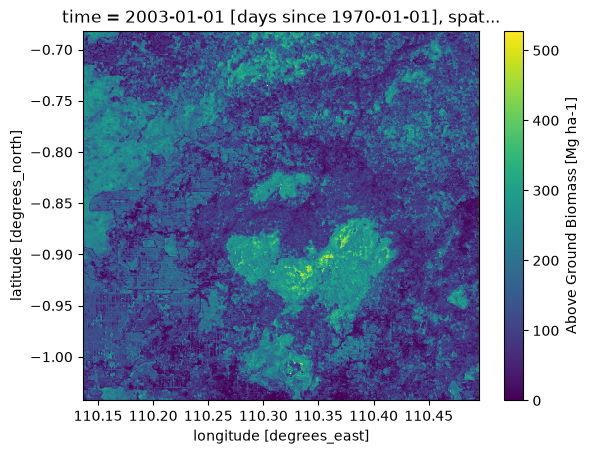

In [67]:
# Another one
da_masked.sel(time=f"{year_two}-01-01").plot()

In [68]:
# Iterate over each year to save a geotiff so we can later create a gif
import matplotlib.pyplot as plt       # Plotting library
import os

script_dir = os.getcwd()  # Get the current working directory
png_dir = os.path.join(script_dir, "CTrees_AGB/")  # Define the directory for saving PNGs

os.makedirs(png_dir, exist_ok=True)  # Create the directory if it doesn't exist

years = range(2000, 2026) # From 2000 to 2025 inclusive


In [72]:
# Compute fixed color scale across all years (use robust percentiles to reduce outlier effect)
q = da_masked.quantile([0.02, 0.98], dim=("time", "y", "x"), skipna=True).compute()
vmin = float(q.sel(quantile=0.02))
vmax = float(q.sel(quantile=0.98))
print(vmax)
# Shared plotting kwargs for consistent colorbar in every frame
plot_kwargs = {
    "vmin": vmin,
    "vmax": vmax,
    "cbar_kwargs": {"label": "AGB (Mg ha-1)"},
}

print(f"Fixed color scale -> vmin: {vmin:.2f}, vmax: {vmax:.2f}")

# In your plotting loop (cell 22), use:
# agb_mesh = da_masked.sel(time=f"{year}-01-01").plot(ax=ax, **plot_kwargs)

302.8999938964844
Fixed color scale -> vmin: 6.40, vmax: 302.90


In [79]:

# Now lets create every plot
print("stuff")

for year in years:
    print(f"Processing {year}...")
    fig, ax = plt.subplots(figsize=(10,10))
    agb_mesh = da_masked.sel(time=f"{year}-01-01").plot(ax=ax, vmin=0, vmax=550)
    
    plt.tight_layout()
    plt.savefig(os.path.join(png_dir, f"ctrees_agb_{year}_20km-buffer_100m.png"), dpi=150)
    plt.close(fig)


stuff
Processing 2000...
Processing 2001...
Processing 2002...
Processing 2003...
Processing 2004...
Processing 2005...
Processing 2006...
Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...
Processing 2025...


In [80]:
# Make a gif from the saved images

from PIL import Image
import os

png_dir = "./CTrees_AGB/"

# Creating a list of the images
images = []
for filename in sorted(os.listdir(png_dir)):
    if(filename.endswith(".png")):
        img = Image.open(os.path.join(png_dir, filename))
        images.append(img)

images[0].save(
    f"./CTrees_AGB/ctrees_agb_2000_2025_{buffer_distance_km}km-buffer_100m.gif",
    save_all=True,
    append_images=images[1:],
    duration=600,
    loop=0
)

In [30]:
# Find AGB values for all years for clipped geometry
# Define no_data_val and apply masking
no_data_val = -9999

# Apply masking for no_data_val and negatives, then scale
cleaned = da_masked.where(da_masked != no_data_val)  # Mask no_data_val
cleaned = cleaned.where(cleaned >= 0, 0)

# Compute total and average AGB for all years at once
stats_df = xr.Dataset(
    data_vars={
        "avg_agb_density": cleaned.mean(dim=("y", "x"), skipna=True).fillna(0),
    }
)

# Convert to pandas DataFrame if needed
stats_df = stats_df.to_dataframe().reset_index()

<Axes: title={'center': 'Average Above Ground Biomass Density'}, xlabel='time'>

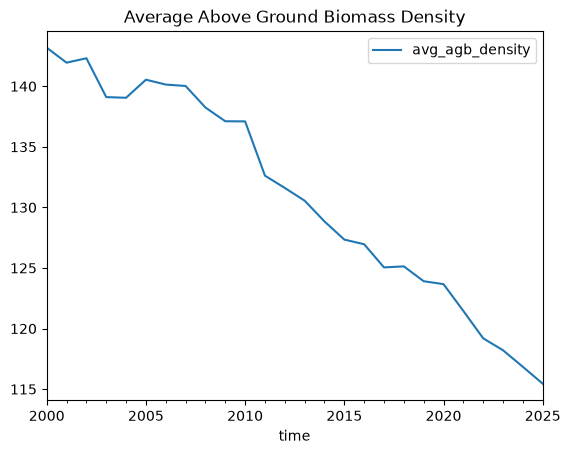

In [31]:
## plot & download time sereis
stats_df.plot(x="time", y="avg_agb_density", title="Average Above Ground Biomass Density")

In [32]:
stats_df

,time,spatial_ref,avg_agb_density
0,2000-01-01,0,143.181870
1,2001-01-01,0,141.945831
2,2002-01-01,0,142.311630
3,2003-01-01,0,139.103302
4,2004-01-01,0,139.049072
5,2005-01-01,0,140.540680
6,2006-01-01,0,140.139435
7,2007-01-01,0,140.022919
8,2008-01-01,0,138.245041
9,2009-01-01,0,137.110123
